# 02 — RFM Computation

This notebook covers data cleaning, window definition, and RFM metric computation.

**Goals:**
- Apply full cleaning pipeline via `src/preprocessing.py`
- Define the observation window and prediction window
- Compute per-customer RFM metrics
- Split data into calibration and holdout periods for BG/NBD validation
- Save processed outputs to `data/processed/`

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings

sys.path.append('..')
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})

DATA_RAW      = '../data/raw/online_retail_II.xlsx'
DATA_PROCESSED = '../data/processed/'
FIGURES_PATH  = '../reports/figures/'

## 2. Load & Clean

We apply the full cleaning pipeline:
- Merge both year sheets
- Drop rows with missing `customer_id`
- Remove cancellation invoices (prefix `C`)
- Remove rows with non-positive `quantity` or `price`
- Compute `total_price = quantity × price`

In [3]:
from src.preprocessing import load_and_clean

df = load_and_clean(DATA_RAW)

print(f"Clean rows      : {len(df):,}")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Unique invoices : {df['invoice'].nunique():,}")
print(f"Date range      : {df['invoice_date'].min().date()} → {df['invoice_date'].max().date()}")
df.head()

Loading data...
Raw shape: 1,067,371 rows

Cleaning...
Removed 19,494 cancellation rows (1.8%)
Removed 3,457 rows with non-positive quantity
Removed 2,750 rows with non-positive price
Removed 236,121 rows with missing customer_id (22.7%)

Clean shape : 805,549 rows
Customers   : 5,878
Date range  : 2009-12-01 → 2011-12-09
Clean rows      : 805,549
Unique customers: 5,878
Unique invoices : 36,969
Date range      : 2009-12-01 → 2011-12-09


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 3. Observation & Prediction Window Definition

Defining clear windows is the most important step before RFM computation.

```
|──────── Calibration ───────────────|── Holdout ──|
Jan 2010                      Oct 2011      Dec 2011
```

- **Calibration period** — used to fit BG/NBD model
- **Holdout period** — used to validate predicted purchases vs actuals
- **Observation end date** — the cutoff point; recency is measured relative to this date

We use the last 2 months as holdout, consistent with common CLV modeling practice.

In [4]:
OBS_START   = pd.Timestamp('2010-01-01')  # drop partial first month
OBS_END     = pd.Timestamp('2011-12-31')  # end of full dataset
HOLDOUT_START = pd.Timestamp('2011-11-01')  # ~2 month holdout

CALIB_END   = HOLDOUT_START - pd.Timedelta(days=1)

print(f"Calibration : {OBS_START.date()} → {CALIB_END.date()}")
print(f"Holdout     : {HOLDOUT_START.date()} → {OBS_END.date()}")

# Filter to observation window
df = df[(df['invoice_date'] >= OBS_START) & (df['invoice_date'] <= OBS_END)].copy()
print(f"\nRows in observation window: {len(df):,}")
print(f"Unique customers          : {df['customer_id'].nunique():,}")

Calibration : 2010-01-01 → 2011-10-31
Holdout     : 2011-11-01 → 2011-12-31

Rows in observation window: 774,795
Unique customers          : 5,789


> **Note on dataset cutoff:** `OBS_END` is defined as `2011-12-31` but the actual last
> transaction in the dataset is **December 9, 2011** — roughly 3 weeks before year end.
> This is not missing data; it is the natural end of the UCI Online Retail II dataset.
> Keep this in mind when interpreting holdout period length — the effective holdout window
> is ~5.5 weeks (Nov 1 – Dec 9), not the full 2 months implied by the date range.

## 4. Calibration / Holdout Split

In [5]:
from src.rfm import calibration_holdout_split

df_calib, df_holdout = calibration_holdout_split(df, HOLDOUT_START)

print(f"Calibration rows : {len(df_calib):,}")
print(f"Holdout rows     : {len(df_holdout):,}")

Calibration : 692,959 rows  (2010-01-04 → 2011-10-31)
Holdout     : 81,836 rows  (2011-11-01 → 2011-12-09)
Calibration rows : 692,959
Holdout rows     : 81,836


## 5. RFM Computation

BG/NBD uses a specific definition of RFM that differs slightly from the
marketing convention:

| Metric | Definition |
|--------|------------|
| **Recency** (`T_x`) | Time between first purchase and last purchase (in weeks) |
| **Frequency** (`frequency`) | Number of **repeat** transactions (total invoices − 1) |
| **T** | Time between first purchase and end of observation window (in weeks) |
| **Monetary** | Average revenue per transaction |

> Note: BG/NBD counts **repeat** transactions, not total. A customer with 1 invoice
> has `frequency = 0` and contributes to parameter estimation but is treated as
> having never repeated.

In [6]:
from src.rfm import compute_rfm

rfm_calib = compute_rfm(df_calib, observation_end=CALIB_END)

print(f"RFM records: {len(rfm_calib):,}")
rfm_calib.head(10)

RFM computed for 5,552 customers
  frequency  — mean: 4.76, max: 345
  recency    — mean: 33.73 W
  T          — mean: 61.67 W
  monetary   — mean: £385.22
RFM records: 5,552


,customer_id,frequency,recency,T,monetary_value,first_purchase,last_purchase,total_invoices
0,12346,6,54.14,94.86,11063.28,2010-01-04 09:24:00,2011-01-18 10:01:00,7
1,12347,6,52.00,52.00,772.64,2010-10-31 14:20:00,2011-10-31 12:25:00,7
2,12348,4,51.71,56.86,403.88,2010-09-27 14:59:00,2011-09-25 13:13:00,5
3,12349,2,25.86,78.43,890.38,2010-04-29 13:20:00,2010-10-28 08:23:00,3
4,12350,0,0.00,38.57,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,1
5,12351,0,0.00,47.86,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,1
6,12352,8,45.71,50.29,282.01,2010-11-12 10:20:00,2011-09-28 14:58:00,9
7,12353,1,29.14,52.57,203.38,2010-10-27 12:44:00,2011-05-19 17:47:00,2
8,12354,0,0.00,27.43,1079.40,2011-04-21 13:11:00,2011-04-21 13:11:00,1
9,12355,1,50.43,75.29,473.80,2010-05-21 11:59:00,2011-05-09 13:49:00,2


In [7]:
rfm_calib.describe().round(3)

,customer_id,frequency,recency,T,monetary_value,first_purchase,last_purchase,total_invoices
count,5552.0,5552.000,5552.000,5552.000,5552.000,5552,5552,5552.000
mean,15310.681,4.765,33.726,61.669,385.222,2010-08-24 20:52:55.914985728,2011-04-18 07:11:30.475504128,5.765
min,12346.0,0.000,0.000,0.290,2.900,2010-01-04 09:24:00,2010-01-05 12:43:00,1.000
25%,13832.75,0.000,0.000,47.430,181.382,2010-03-08 11:31:45,2010-11-16 13:37:45,1.000
50%,15306.5,2.000,25.640,69.290,289.405,2010-07-02 10:52:30,2011-06-23 17:34:00,3.000
75%,16786.25,5.000,64.710,85.860,429.227,2010-12-02 12:36:30,2011-09-29 18:14:15,6.000
max,18287.0,345.000,95.000,94.860,14844.770,2011-10-28 17:27:00,2011-10-31 17:13:00,346.000
std,1712.69,11.674,32.873,27.758,557.802,NaN,NaN,11.674


### Key Observations from RFM Summary

**Frequency outlier:**
The max frequency of **345** is a significant outlier — this customer made 346 total
purchases during calibration (~3.6 per week on average). This is likely a very active
wholesale account or potentially a data aggregation artifact. Consider investigating
this customer before BG/NBD fitting, as extreme outliers can skew parameter estimation.

**Recency vs T gap:**
Mean T = **61.67 weeks**, mean recency = **33.73 weeks** — on average, customers were
first observed ~62 weeks ago but their last purchase was only ~34 weeks into their tenure.
This implies a typical customer has been silent for roughly **28 weeks** by the end of
calibration, which the BG/NBD model will interpret as a moderate dropout signal.

**Monetary right skew:**
Mean monetary value of **£385** with a max of **£14,844** confirms a heavily right-skewed
distribution typical of B2B wholesale. The Gamma-Gamma model can handle this, but the
top outliers may disproportionately influence CLV estimates — worth monitoring in notebook 03.

## 6. RFM Distributions

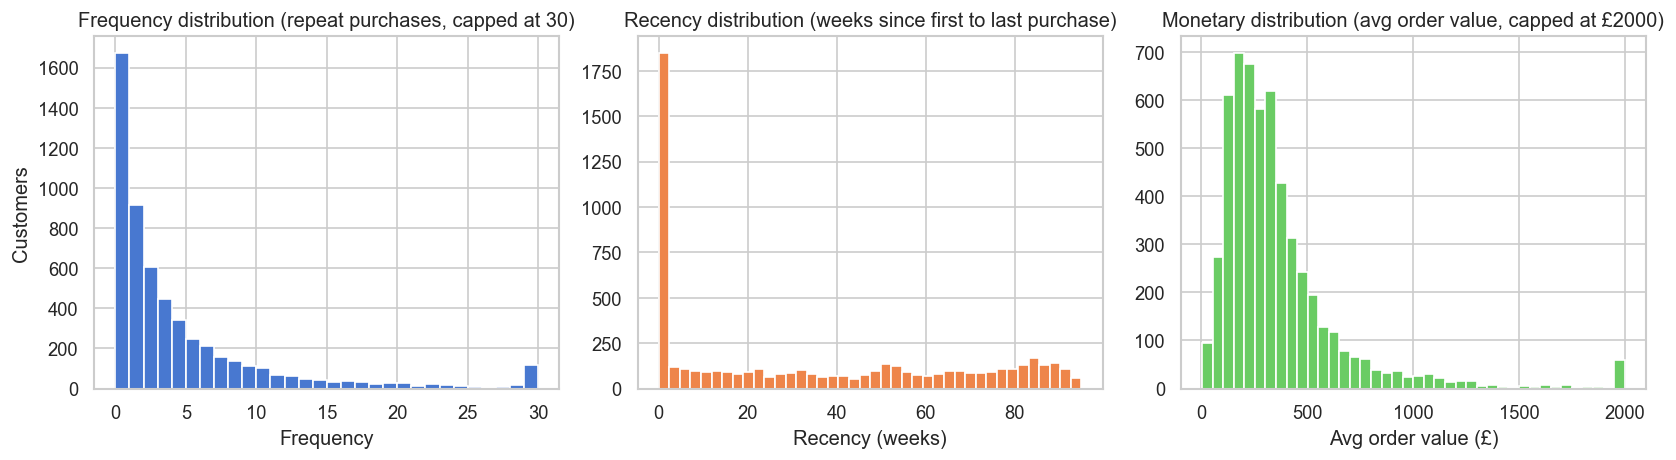

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rfm_calib['frequency'].clip(upper=30), bins=30,
             color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Frequency distribution (repeat purchases, capped at 30)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Customers')

axes[1].hist(rfm_calib['recency'], bins=40,
             color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_title('Recency distribution (weeks since first to last purchase)')
axes[1].set_xlabel('Recency (weeks)')

axes[2].hist(rfm_calib['monetary_value'].clip(upper=2000), bins=40,
             color=sns.color_palette('muted')[2], edgecolor='white')
axes[2].set_title('Monetary distribution (avg order value, capped at £2000)')
axes[2].set_xlabel('Avg order value (£)')

plt.tight_layout()
plt.savefig(FIGURES_PATH + '02_rfm_distributions.png', bbox_inches='tight')
plt.show()

## 7. Zero-Frequency Customers

Customers who purchased only once during calibration have `frequency = 0`.
BG/NBD can handle these, but a high proportion reduces model estimation quality.

In [9]:
zero_freq = (rfm_calib['frequency'] == 0).sum()
total_cust = len(rfm_calib)

print(f"Customers with frequency = 0 : {zero_freq:,} ({zero_freq/total_cust*100:.1f}%)")
print(f"Customers with frequency >= 1: {total_cust - zero_freq:,} ({(total_cust - zero_freq)/total_cust*100:.1f}%)")

Customers with frequency = 0 : 1,673 (30.1%)
Customers with frequency >= 1: 3,879 (69.9%)


> **Why is this slightly higher than EDA?**
> In EDA we observed ~27.6% one-time buyers across the full dataset. Here we see **30.1%**
> in calibration only — the difference is expected. Some customers who bought once during
> calibration went on to purchase again in the holdout period, so they appear as one-time
> buyers at the calibration cutoff but are not truly one-time buyers overall.
> This is a natural consequence of the calibration/holdout split, not a data issue.
> The 69.9% repeat buyer rate remains a strong positive signal for BG/NBD parameter estimation.

## 8. Holdout Actual Purchase Counts

We compute the actual number of purchases each customer made in the holdout period.
This will be used in `03_bgnbd_model.ipynb` to validate BG/NBD predictions.

In [10]:
holdout_actuals = (
    df_holdout
    .groupby('customer_id')['invoice']
    .nunique()
    .reset_index()
    .rename(columns={'invoice': 'actual_purchases_holdout'})
)

# Merge with calibration RFM — customers with 0 holdout purchases get 0
rfm_calib = rfm_calib.merge(holdout_actuals, on='customer_id', how='left')
rfm_calib['actual_purchases_holdout'] = rfm_calib['actual_purchases_holdout'].fillna(0).astype(int)

print("Holdout purchase distribution:")
print(rfm_calib['actual_purchases_holdout'].describe().round(2))

Holdout purchase distribution:
count    5552.00
mean        0.56
std         1.49
min         0.00
25%         0.00
50%         0.00
75%         1.00
max        54.00
Name: actual_purchases_holdout, dtype: float64


### Key Observations from Holdout Distribution

**Median = 0:** More than 50% of customers made zero purchases in the 2-month holdout window.
This is expected behavior for a wholesale dataset — not every customer buys every 2 months.
It means BG/NBD must be evaluated primarily at the **aggregate level** (total predicted vs
total actual purchases across all customers) rather than individual-level accuracy.

**Heavy tail:** The max of **54** holdout purchases from a single customer is consistent
with the frequency=345 outlier seen in calibration — the same high-volume accounts dominate
both periods. These extreme buyers will have an outsized effect on aggregate validation metrics,
so it's worth reporting results both with and without the top 1% of buyers.

## 9. Save Processed Outputs

In [11]:
import os
import pyarrow as pa
import pyarrow.parquet as pq

os.makedirs(DATA_PROCESSED, exist_ok=True)

# Force all object columns to string to prevent PyArrow type inference errors
# (stock_code contains mixed values like '82494L', 'POST', etc.)
def safe_to_parquet(df, path):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str)
    df.to_parquet(path, index=False)

safe_to_parquet(rfm_calib, DATA_PROCESSED + 'rfm_calibration.parquet')
safe_to_parquet(df_holdout, DATA_PROCESSED + 'transactions_holdout.parquet')
safe_to_parquet(df_calib,   DATA_PROCESSED + 'transactions_calibration.parquet')

print("Saved:")
print(f"  rfm_calibration.parquet          — {len(rfm_calib):,} rows")
print(f"  transactions_calibration.parquet — {len(df_calib):,} rows")
print(f"  transactions_holdout.parquet     — {len(df_holdout):,} rows")

Saved:
  rfm_calibration.parquet          — 5,552 rows
  transactions_calibration.parquet — 692,959 rows
  transactions_holdout.parquet     — 81,836 rows


## 10. Summary & Next Steps

### What we have now

| Output | Description |
|--------|-------------|
| `rfm_calibration.parquet` | Per-customer RFM + actual holdout purchases |
| `transactions_calibration.parquet` | Clean transaction data for calibration period |
| `transactions_holdout.parquet` | Clean transaction data for holdout period |

### Next Steps

Proceed to `03_bgnbd_model.ipynb` to:
- Fit BG/NBD model on `rfm_calibration`
- Validate fit using frequency-recency matrix and tracking plot
- Generate `p_alive` scores and predicted purchases per customer
- Fit Gamma-Gamma model for CLV estimation